In [1]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTE

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [4]:
# Drop diseases with less than 50 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 750].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 114
Number of rows left: 114312


In [5]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
20     1002
9      1002
66     1002
80     1002
1      1002
       ... 
40     1002
106    1002
54     1002
102    1002
88     1002
Name: count, Length: 114, dtype: int64
Number of remaining classes in training set: 114
Number of rows in the resampled training set: 114228


In [6]:
# Optuna optimization function
def objective(trial):
    # Define the hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 150)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Create RandomForestClassifier with hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    # Perform cross-validation (using 5-fold by default)
    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    accuracy = score.mean()

    # Log the hyperparameters and accuracy for this trial
    print(f"Trial {trial.number}: n_estimators={n_estimators}, max_depth={max_depth}, "
          f"min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}, "
          f"max_features={max_features}, Accuracy={accuracy:.4f}")

    return accuracy

In [8]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="randomforest_diseases_symptoms_dropextremelymore750withSMOTE_SecondAugmentation_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/randomforest.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-22 19:26:07,670] A new study created in RDB with name: randomforest_diseases_symptoms_dropextremelymore750withSMOTE_SecondAugmentation_study
[I 2025-04-22 19:26:21,070] Trial 0 finished with value: 0.6942343120658278 and parameters: {'n_estimators': 58, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 0 with value: 0.6942343120658278.


Trial 0: n_estimators=58, max_depth=27, min_samples_split=15, min_samples_leaf=16, max_features=log2, Accuracy=0.6942


[I 2025-04-22 19:28:32,137] Trial 1 finished with value: 0.6386262927274222 and parameters: {'n_estimators': 96, 'max_depth': 34, 'min_samples_split': 20, 'min_samples_leaf': 18, 'max_features': None}. Best is trial 0 with value: 0.6942343120658278.


Trial 1: n_estimators=96, max_depth=34, min_samples_split=20, min_samples_leaf=18, max_features=None, Accuracy=0.6386


[I 2025-04-22 19:28:47,239] Trial 2 finished with value: 0.7002223438380138 and parameters: {'n_estimators': 55, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 14, 'max_features': 'log2'}. Best is trial 2 with value: 0.7002223438380138.


...

Trial 17: n_estimators=131, max_depth=10, min_samples_split=9, min_samples_leaf=11, max_features=log2, Accuracy=0.6542


[I 2025-04-22 19:39:50,679] Trial 18 finished with value: 0.7040918524055373 and parameters: {'n_estimators': 134, 'max_depth': 43, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 15 with value: 0.7049847850290794.


Trial 18: n_estimators=134, max_depth=43, min_samples_split=17, min_samples_leaf=2, max_features=sqrt, Accuracy=0.7041


[I 2025-04-22 19:42:30,618] Trial 19 finished with value: 0.6529748325628946 and parameters: {'n_estimators': 117, 'max_depth': 36, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 15 with value: 0.7049847850290794.


Trial 19: n_estimators=117, max_depth=36, min_samples_split=13, min_samples_leaf=8, max_features=None, Accuracy=0.6530

Best Trial:
FrozenTrial(number=15, state=TrialState.COMPLETE, values=[0.7049847850290794], datetime_start=datetime.datetime(2025, 4, 22, 19, 37, 29, 683839), datetime_complete=datetime.datetime(2025, 4, 22, 19, 38, 5, 536292), params={'n_estimators': 142, 'max_depth': 37, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_features': 'log2'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=150, log=False, low=50, step=1), 'max_depth': IntDistribution(high=50, log=False, low=10, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=20, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None))}, trial_id=473, value=None)
Best Hyperparameters:
{'n_estimators': 142, 'max_depth': 37, 'min_samples_split': 

Model has been trained and saved successfully.


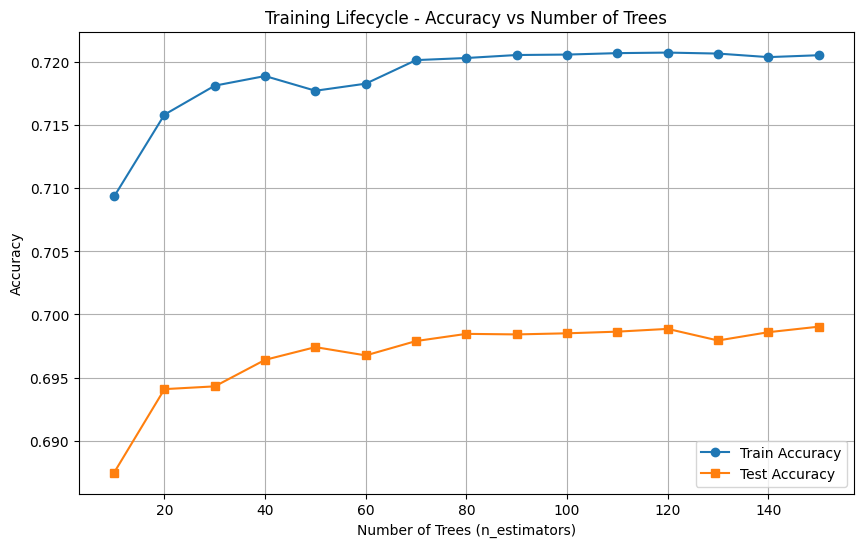

In [8]:
import joblib
import matplotlib.pyplot as plt

# Load existing study from the database
study = optuna.load_study(
    study_name="randomforest_diseases_symptoms_dropextremelymore750withSMOTE_SecondAugmentation_study",
    storage="sqlite:///C:/Users/khiew/Downloads/randomforest.db"
)

# 1. Create model with best parameters
best_params = study.best_trial.params
best_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# 2. Train model on the resampled training data
best_model.fit(X_train_resampled, y_train_resampled)

# 3. Save the trained model to a file
joblib.dump(best_model, r'C:\Users\khiew\Downloads\second_best_randomforest_model.joblib')

print("Model has been trained and saved successfully.")

# ==========================
# Plotting Training Lifecycle
# ==========================

# Let's simulate a "training curve" by varying number of trees
n_estimators_list = list(range(10, best_params['n_estimators']+10, 10))  # steps of 10 trees
train_accuracies = []
test_accuracies = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42
    )
    model.fit(X_train_resampled, y_train_resampled)

    # Train accuracy
    y_train_pred = model.predict(X_train_resampled)
    train_acc = accuracy_score(y_train_resampled, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Training Lifecycle - Accuracy vs Number of Trees')
plt.legend()
plt.grid(True)
plt.show()
